### Persons in the geographical space

We present various methods of spatialising the birthplaces of our population.

The data was prepared using the queries [documented on this page](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da2-birth-places.sql)

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
from shapely import wkt

import scipy.stats as stats

from geopandas.tools import sjoin
#from geodatasets import get_path

In [2]:
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

import json

import numpy as np
import seaborn as sns
import math
import os

In [3]:
import warnings
warnings.filterwarnings('ignore')


In [4]:

import pprint
import csv


from shutil import copyfile


## Geo data

Documentation: [Geographical Information System](https://en.wikipedia.org/wiki/Geographic_information_system) (Wikipedia)

<img src=./doc_images/DatendimensionenImGIS.jpg alt="geodata" width="50%">  
Par F Lamiot d'après [1] (GNUFDL) — source, CC BY-SA 3.0, https://commons.wikimedia.org/w/index.php?curid=3831140


### Source des données spatiales
[Word Regions (ESRI)](https://hub.arcgis.com/datasets/a79a3e4dc55343b08543b1b6133bfb90/explore?location=-0.027457%2C0.000000%2C0.88). For personal use only, data under copyright !

In [5]:
world_filepath = 'geo_data/World_Regions_6144914380456424035.geojson'
## dataframe GeoPandas
world = gpd.read_file(world_filepath)
world.head()

,FID,REGION,SQMI,SQKM,geometry
0,1,Asiatic Russia,4.987737e+06,1.291823e+07,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,2,Australia/New Zealand,3.077219e+06,7.969992e+06,"MULTIPOLYGON (((158.88218 -54.71139, 158.87967..."
2,3,Caribbean,8.919361e+04,2.310113e+05,"MULTIPOLYGON (((-60.92305 10.79722, -60.94445 ..."
3,4,Central America,9.576923e+05,2.480422e+06,"MULTIPOLYGON (((-81.67847 7.38861, -81.64945 7..."
4,5,Central Asia,1.612212e+06,4.175626e+06,"POLYGON ((53.90564 37.35086, 53.67731 37.33536..."


### Basic GIS notions

* [Geographic information system - GIS](https://en.wikipedia.org/wiki/Geographic_information_system)
* [Geoid](https://en.wikipedia.org/wiki/Geoid)
* [Earth ellipsoid](https://en.wikipedia.org/wiki/Earth_ellipsoid): WGS84
* [Spatial reference system - SRS/CRS](https://en.wikipedia.org/wiki/Spatial_reference_system)
* [EPSG Geodetic Parameter Dataset](https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset): EPSG:4326, EPSG:3857, EPSG:9989

In [6]:
### Inspect the projection
pprint.pprint(world.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



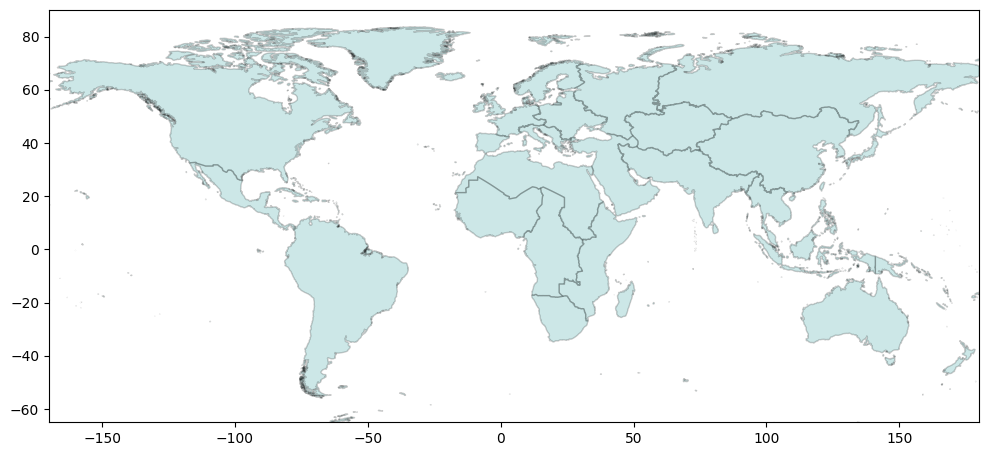

In [7]:
### Draw the world map

## GeoPandas documentation
# https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html

# If we want to exclude the Antarctic region
world.clip([-180.0, -10.0, 180.0, 90.0])

ax = world.plot(color="DarkCyan", alpha=0.2, edgecolor="black", figsize=(12,9))

# If we want to exclude the Antarctic region
ax.set_xlim(-170,180)
ax.set_ylim(-65, 90)


plt.show()



## Import the data

The data is available in the da_data directory and was prepared using the query [documented on this page](../../documentation/wikidata/data-analysis/da1-distribution-of-births-in-time.md)

In [13]:
## create variable declaring the path to the data
path_to_data = 'da2-birth-place.csv'

In [14]:
## creating a Pandas Dataframe (data container in form of a table) 
df_p = pd.read_csv(path_to_data, sep=",", encoding="utf-8", header=0)
df_p.columns = ['uriPer', 'labelPer', 'birthYear', 'gender', 'labelPlace',
                'geometry','uriPlace']

## first rows of the dataframe
df_p.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace
0,http://www.wikidata.org/entity/Q104599786,Maria Cristina Messa,1961,femmina,Monza,POINT(9.273611 45.583611),http://www.wikidata.org/entity/Q6252
1,http://www.wikidata.org/entity/Q105296748,Daniele Franco,1953,maschio,Trichiana,POINT(12.134445 46.074444),http://www.wikidata.org/entity/Q40468
2,http://www.wikidata.org/entity/Q105320865,Patrizio Bianchi,1952,maschio,Copparo,POINT(11.833333 44.900000),http://www.wikidata.org/entity/Q95098
3,http://www.wikidata.org/entity/Q1053876,Randolfo Pacciardi,1899,maschio,Giuncarico,POINT(10.991945 42.906945),http://www.wikidata.org/entity/Q2456297
4,http://www.wikidata.org/entity/Q1055104,Pietro Lunardi,1939,maschio,Parma,POINT(10.328000 44.801472),http://www.wikidata.org/entity/Q2683


In [15]:
## Basic infor about the DataFrame
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575 entries, 0 to 574
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   uriPer      575 non-null    object
 1   labelPer    572 non-null    object
 2   birthYear   575 non-null    int64 
 3   gender      575 non-null    object
 4   labelPlace  575 non-null    object
 5   geometry    575 non-null    object
 6   uriPlace    575 non-null    object
dtypes: int64(1), object(6)
memory usage: 31.6+ KB


## Inspect the data


In [16]:
### Add column names and inspect length of dataframe

print('Number: ',len(df_p))
df_p.iloc[10:13,:]

Number:  575


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace
10,http://www.wikidata.org/entity/Q1071031,Paolo Gentiloni,1954,maschio,Roma,POINT(12.482778 41.893056),http://www.wikidata.org/entity/Q220
11,http://www.wikidata.org/entity/Q1071053,Cesare Damiano,1948,maschio,Cuneo,POINT(7.550000 44.383333),http://www.wikidata.org/entity/Q5968
12,http://www.wikidata.org/entity/Q1071082,Barbara Pollastrini,1947,femmina,Darfo Boario Terme,POINT(10.186667 45.894444),http://www.wikidata.org/entity/Q104565


### Treat multiple birth places

Verify that persons are unique:
* are there some persons with multiple birth places, etc.?
  * If Pandas *is_unique* method: 'true' they are unique, so no multiple.
  * If 'false': multiple rows per person
* If you have multiple persons go back to the SQL part and clean up using GROUP BY -> MIN  

In [17]:
### Tests if the values in the column are unique
# If unique result : True (boolean value not string !)
is_unique=df_p.uriPer.is_unique
print(is_unique)

True


## Group and map birth places

"Well-known text (WKT) is a text markup language for representing vector geometry objects" ([Wikipedia](https://en.wikipedia.org/wiki/Well-known_text_representation_of_geometry))

In [18]:
### Group and count the number of persons per birth place
p_gr = df_p.groupby(by=['uriPlace', 'labelPlace', 'geometry'], as_index=False).size()
p_gr.columns=['uriPlace', 'labelPlace', 'geometry', 'size']
p_gr.sort_values('size', ascending=False).head()


,uriPlace,labelPlace,geometry,size
93,http://www.wikidata.org/entity/Q220,Roma,POINT(12.482778 41.893056),67
171,http://www.wikidata.org/entity/Q490,Milano,POINT(9.190000 45.466944),31
103,http://www.wikidata.org/entity/Q2634,Napoli,POINT(14.248611 40.835833),22
173,http://www.wikidata.org/entity/Q495,Torino,POINT(7.676111 45.079167),15
72,http://www.wikidata.org/entity/Q1891,Bologna,POINT(11.342778 44.493889),12


In [19]:
### Try first to convert WKT into Point Geometry
# using a geopandas feature
try:
    p_gr['geometry'] = p_gr['geometry'].apply(wkt.loads)
except Exception as e:
    print(e)

In [20]:
### there are wrong values in the data: find them
# all the rows where the geometry field does not contain the string 'POINT'
df_p.loc[~df_p.geometry.str.contains('POINT')]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace


In [21]:
### Drop the rows with the wrong value
df_p=df_p.loc[df_p.geometry.str.contains('POINT')]

In [22]:
### Re-do grouping after cleaning up
p_gr = df_p.groupby(by=['uriPlace', 'labelPlace', 'geometry'], as_index=False).size()
p_gr.columns=['uriPlace', 'labelPlace', 'geometry', 'number']
p_gr.sort_values('number', ascending=False).head(2)


,uriPlace,labelPlace,geometry,number
93,http://www.wikidata.org/entity/Q220,Roma,POINT(12.482778 41.893056),67
171,http://www.wikidata.org/entity/Q490,Milano,POINT(9.190000 45.466944),31


In [23]:

### Create a dataframe with the POINT geometry
# https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html
birth_gdf = gpd.GeoDataFrame(
    p_gr, 
    ### Use this if no conversion before to geometry
    ## Cf. above:  p_gr['geometry'].apply(wkt.loads)
    geometry=gpd.GeoSeries.from_wkt(p_gr.geometry), 
    crs=4326
)

birth_gdf.sort_values('number', ascending=False).head(2)



,uriPlace,labelPlace,geometry,number
93,http://www.wikidata.org/entity/Q220,Roma,POINT (12.48278 41.89306),67
171,http://www.wikidata.org/entity/Q490,Milano,POINT (9.19 45.46694),31


In [24]:
### The Python class of the object changed 
# WKT strings are now points
print(p_gr.geometry.dtype, '->', birth_gdf.geometry.dtype)

object -> geometry


In [25]:
### Inspect the projection
pprint.pprint(birth_gdf.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



In [26]:
### Draw the world map


ax = world.plot(color="LightCyan", alpha=0.3, 
                edgecolor="black", linewidth=2, figsize=(64,48))

# If we want to exclude the Antarctic region
ax.set_xlim(-170,180)
ax.set_ylim(-60, 80)

# We can now plot our ``GeoDataFrame``.
birth_gdf.plot(ax=ax, color="DarkRed", markersize='number', alpha=0.5)
# Add labels where number > 100
for _, row in birth_gdf[birth_gdf['number'] > 50].iterrows():
    ax.annotate(
        text=row['labelPlace'],          # e.g. "Boston"
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),              # offset in points
        textcoords="offset points",
        fontsize=7,
        color="Black",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="none",
            alpha=0.7
        )
    )

f_address = "images/birth_places_geopandas.png"
plt.savefig(f_address)
# plt.show()
print('Done -> inspect picture')
plt.close()

Done -> inspect picture


## Experiment with different maps types

In [27]:
birth_gdf.head(1)

,uriPlace,labelPlace,geometry,number
0,http://www.wikidata.org/entity/Q100113,Zocca,POINT (10.99041 44.34726),1


In [28]:
### Create columns for long / lat
birth_gdf['long'] = birth_gdf['geometry'].x
birth_gdf['lat'] = birth_gdf['geometry'].y
birth_gdf.head(1)

,uriPlace,labelPlace,geometry,number,long,lat
0,http://www.wikidata.org/entity/Q100113,Zocca,POINT (10.99041 44.34726),1,10.990407,44.347264


In [29]:
birth_gdf_plus1 = birth_gdf.loc[birth_gdf.number>1]
print(birth_gdf_plus1[["lat", "long"]].head(10))
print(birth_gdf_plus1[["lat", "long"]].describe())
print(birth_gdf_plus1.crs)

          lat       long
5   45.521389   9.592778
9   43.662500  10.632778
21  40.680556  14.759444
23  44.592500  10.687778
24  45.611958   8.851800
28  45.810250   9.086139
34  44.308056   8.481111
36  44.700000  10.633333
37  44.839167  11.617500
40  43.716667  10.400000
             lat       long
count  78.000000  78.000000
mean   42.404762  12.603864
std     4.182641   4.011957
min    15.333333   7.550000
25%    40.734236  10.244378
50%    43.689583  12.237776
75%    45.352154  14.507570
max    46.169720  38.916667
EPSG:4326


In [30]:
import math
# p_size = [int(s/10+2) for s in birth_gdf_plus1['number']]
# p_size = [int(s) for s in birth_gdf_plus1['number']]
p_size = [(math.log(s)) for s in birth_gdf_plus1['number']]
max(p_size)

4.204692619390966

In [31]:

fig = px.scatter_map(
    birth_gdf_plus1, lat="lat", lon="long", size=p_size,
    hover_name="labelPlace", hover_data=["number"],
    opacity=0.8, zoom=3.5,
    center=dict(lon=8.5, lat=47),
    height=1000
)

fig.update_traces(marker=dict(color="GreenYellow", sizemin=0.2))

fig.update_layout(
    map=dict(
        style={
            "version": 8,
            "sources": {
                "usgs": {
                    "type": "raster",
                    "tiles": ["https://basemap.nationalmap.gov/arcgis/rest/services/USGSImageryOnly/MapServer/tile/{z}/{y}/{x}"],
                    "tileSize": 256
                }
            },
            "layers": [{
                "id": "usgs-layer",
                "type": "raster",
                "source": "usgs"
            }]
        },
        center=dict(lon=8.5, lat=47),
        zoom=3.5
    )
)

#fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
f_address = "interactive_images/birth_places_geological_survey.html"
fig.write_html(f_address)
print('Done -> inspect picture')
#fig.show()
plt.close()

FileNotFoundError: [Errno 2] No such file or directory: 'interactive_images/birth_places_geological_survey.html'

In [32]:
### Open the world regions ESRI file in geojson format (and not dataframe)
with open('geo_data/World_Regions_6144914380456424035.geojson') as f:
    geojson = json.load(f)

geojson['features'][3]['properties']


{'FID': 4,
 'REGION': 'Central America',
 'SQMI': 957692.30734,
 'SQKM': 2480421.615}

In [33]:
### 

p_size = [int(s/10+2) for s in birth_gdf_plus1['number']]

fig = px.scatter_map(birth_gdf_plus1, lat="lat", lon="long", size=p_size, 
                     hover_name="labelPlace", 
                        color_discrete_sequence=["DodgerBlue"],  zoom=3.5,
                        center=dict(lon=8.5, lat=47),height=600,
                        opacity=0.9)
fig.update_layout(
    map_style="white-bg",
    map_layers=[
        {
            "below": 'traces',
            "sourcetype": "geojson",
            "type":"line",
            "sourceattribution": "ESRI",
            "source": geojson,
            "line": {"width": 0.5},
        }
      ])

f_address = "interactive_images/birth_places_regions.html"
fig.write_html(f_address)
#fig.show()

FileNotFoundError: [Errno 2] No such file or directory: 'interactive_images/birth_places_regions.html'

### Plot the world as a sphere

In [ ]:
### Plot on world as a sphere

lon = birth_gdf["long"]
lat= birth_gdf["lat"]
label= birth_gdf["labelPlace"]
size=[s/10 + 3 for s in birth_gdf["number"]]


# Create the figure
fig = go.Figure(data=go.Scattergeo(
    lon=lon,
    lat=lat,
    mode='markers+text',
    marker=dict(size=size,
                color='red'),
    hovertext=label,
    textposition='top center',
    hoverinfo='text',
    hoverlabel=dict(
        bgcolor='white',
        font_size=12,
        font_family='Arial'
    )
))

# Set the projection to orthogonal
fig.update_layout(
    width=800, 
    height=800,
    geo=dict(
        projection=dict(
            type='orthographic'
        )
    )
)

f_address = "interactive_images/birth_places_globus.html"
fig.write_html(f_address)
# Show the plot
#fig.show()

### Join regions and inspect

We use here spatial joins and associate a region to each place

In [34]:
birth_gdf.loc[birth_gdf.labelPlace.str.contains('Petersburg') |
              birth_gdf.labelPlace.str.contains('Moscow')
              ].sort_values('number', ascending=False).head(10)

,uriPlace,labelPlace,geometry,number,long,lat


In [35]:
### GeoPandas spatial join

w_birth_gdf= birth_gdf.sjoin(world)
w_birth_gdf.iloc[[1,5,10]]

,uriPlace,labelPlace,geometry,number,long,lat,index_right,FID,REGION,SQMI,SQKM
1,http://www.wikidata.org/entity/Q100123,Calcinate,POINT (9.8003 45.6212),1,9.800300,45.621200,18,19,Southern Europe,503015.12202,1.302808e+06
5,http://www.wikidata.org/entity/Q101685,Treviglio,POINT (9.59278 45.52139),2,9.592778,45.521389,18,19,Southern Europe,503015.12202,1.302808e+06
10,http://www.wikidata.org/entity/Q103244,San Miniato,POINT (10.85 43.68333),1,10.850000,43.683333,18,19,Southern Europe,503015.12202,1.302808e+06


In [36]:
### Number of regions
print(len(world))
world.head(1)

25


,FID,REGION,SQMI,SQKM,geometry
0,1,Asiatic Russia,4.987737e+06,12918232.32,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [37]:
### Count by region (sum number of each place in the region)
swb = w_birth_gdf.groupby(['FID','REGION'], as_index=False)['number'].sum()
#swb = swb.set_index('FID', drop=False)
print(len(swb))
swb.sort_values('number', ascending=False).head(24)


7


,FID,REGION,number
3,19,Southern Europe,551
5,22,Western Europe,2
0,6,Eastern Africa,2
2,13,Northern Africa,1
1,12,Middle Africa,1
4,20,Western Africa,1
6,24,Northern Europe,1


In [38]:
### Find places in European Russia with most births 
w_birth_gdf.loc[w_birth_gdf.FID==9].sort_values('number',ascending=False).head(2)

,uriPlace,labelPlace,geometry,number,long,lat,index_right,FID,REGION,SQMI,SQKM


In [39]:
### Normal Pandas join: add polygons to aggregated regions 
geom_swb=pd.merge(world, swb, left_on='FID', right_on='FID', 
                  how='left')

geom_swb.head(3)

,FID,REGION_x,SQMI,SQKM,geometry,REGION_y,number
0,1,Asiatic Russia,4.987737e+06,1.291823e+07,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580...",NaN,NaN
1,2,Australia/New Zealand,3.077219e+06,7.969992e+06,"MULTIPOLYGON (((158.88218 -54.71139, 158.87967...",NaN,NaN
2,3,Caribbean,8.919361e+04,2.310113e+05,"MULTIPOLYGON (((-60.92305 10.79722, -60.94445 ...",NaN,NaN


In [40]:
"""grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)
"""
### simplify geometry 
## https://www.statology.org/how-to-simplify-geographic-data-using-geopandas/
geom_swb["geometry"] = (
    geom_swb.simplify(tolerance=0.5)
)

In [41]:
### range
max = geom_swb.number.max()

# Create the choropleth map
fig = px.choropleth_map(
    geom_swb,
    geojson=geom_swb.__geo_interface__,
    map_style='white-bg',
    locations=geom_swb.index,
    color='number',  # Replace with your actual column name
    color_continuous_scale='Blues',
    range_color=(0, max),  # Replace with your actual range
    zoom=1,
    hover_name='REGION_x',
    center={'lat': 47, 'lon': 8.5},
    height=600,
    width=800

)

f_address = "interactive_images/birth_places_regions_choropleth.html"
fig.write_html(f_address)
# Show the plot
#fig.show()

FileNotFoundError: [Errno 2] No such file or directory: 'interactive_images/birth_places_regions_choropleth.html'

## Analyse using periods

In [42]:
### Imputed activity periods
l_10 = list(range(1781, 1991, 10))
print(l_10[:5],l_10[-5:])

[1781, 1791, 1801, 1811, 1821] [1941, 1951, 1961, 1971, 1981]


In [43]:
### convert birthYear to integer
df_p.birthYear = df_p.birthYear.apply(lambda x : int(x))

In [44]:
try:
    df_p = df_p.drop('len_coord', axis=1)
except Exception as e:
    print(e)
df_p.head(2)

"['len_coord'] not found in axis"


,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace
0,http://www.wikidata.org/entity/Q104599786,Maria Cristina Messa,1961,femmina,Monza,POINT(9.273611 45.583611),http://www.wikidata.org/entity/Q6252
1,http://www.wikidata.org/entity/Q105296748,Daniele Franco,1953,maschio,Trichiana,POINT(12.134445 46.074444),http://www.wikidata.org/entity/Q40468


In [45]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année
df_p['periods'] = pd.cut(df_p['birthYear'], l_10, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
df_p['periods'] = df_p['periods'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

df_p=df_p.sort_values(by='periods')

# Inspection
df_p.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods
356,http://www.wikidata.org/entity/Q3839683,Luigi Gasparotto,1873,maschio,Sacile,POINT(12.502740 45.954120),http://www.wikidata.org/entity/Q53190,1871-1880
310,http://www.wikidata.org/entity/Q3766583,Giovanni Battista Bertone,1874,maschio,Mondovì,POINT(7.816667 44.383333),http://www.wikidata.org/entity/Q20188,1871-1880
234,http://www.wikidata.org/entity/Q3677447,Cipriano Facchinetti,1889,maschio,Campobasso,POINT(14.668400 41.561000),http://www.wikidata.org/entity/Q3497,1881-1890


In [46]:
p_gr_per = df_p.groupby(by=['uriPlace', 'labelPlace', 'periods', 'geometry'], observed=True, as_index=False).size()
p_gr_per.columns=['uriPlace', 'labelPlace', 'period', 'coordinates', 'size']
#p_grp.geometry = gpd.GeoSeries.from_wkt(p_gr["coordinates"])
p_gr_per=p_gr_per.sort_values(by='period')
p_gr_per.head()


,uriPlace,labelPlace,period,coordinates,size
130,http://www.wikidata.org/entity/Q19372,Carrù,1871-1880,POINT(7.883333 44.483333),1
134,http://www.wikidata.org/entity/Q20188,Mondovì,1871-1880,POINT(7.816667 44.383333),1
310,http://www.wikidata.org/entity/Q53190,Sacile,1871-1880,POINT(12.502740 45.954120),1
107,http://www.wikidata.org/entity/Q185619,Cernusco sul Naviglio,1871-1880,POINT(9.333333 45.516667),1
305,http://www.wikidata.org/entity/Q52236,Montignoso,1871-1880,POINT(10.166667 44.016667),1


In [47]:

### Créer un dataframe geopandas avec une colonne contenant une géométrie 
# https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html
birth_p_grp = gpd.GeoDataFrame(
    p_gr_per, 
    ### Here we use it
    geometry=gpd.GeoSeries.from_wkt(p_gr_per.coordinates), crs=4326
)

birth_p_grp.head(3)



,uriPlace,labelPlace,period,coordinates,size,geometry
130,http://www.wikidata.org/entity/Q19372,Carrù,1871-1880,POINT(7.883333 44.483333),1,POINT (7.88333 44.48333)
134,http://www.wikidata.org/entity/Q20188,Mondovì,1871-1880,POINT(7.816667 44.383333),1,POINT (7.81667 44.38333)
310,http://www.wikidata.org/entity/Q53190,Sacile,1871-1880,POINT(12.502740 45.954120),1,POINT (12.50274 45.95412)


In [48]:
### Create columns for long / lat
birth_p_grp['long'] = birth_p_grp['geometry'].x
birth_p_grp['lat'] = birth_p_grp['geometry'].y
birth_p_grp.head()

,uriPlace,labelPlace,period,coordinates,size,geometry,long,lat
130,http://www.wikidata.org/entity/Q19372,Carrù,1871-1880,POINT(7.883333 44.483333),1,POINT (7.88333 44.48333),7.883333,44.483333
134,http://www.wikidata.org/entity/Q20188,Mondovì,1871-1880,POINT(7.816667 44.383333),1,POINT (7.81667 44.38333),7.816667,44.383333
310,http://www.wikidata.org/entity/Q53190,Sacile,1871-1880,POINT(12.502740 45.954120),1,POINT (12.50274 45.95412),12.502740,45.954120
107,http://www.wikidata.org/entity/Q185619,Cernusco sul Naviglio,1871-1880,POINT(9.333333 45.516667),1,POINT (9.33333 45.51667),9.333333,45.516667
305,http://www.wikidata.org/entity/Q52236,Montignoso,1871-1880,POINT(10.166667 44.016667),1,POINT (10.16667 44.01667),10.166667,44.016667


In [49]:
# now just plot it on a map with evolution by time
# https://plotly.com/python/animations/
# https://plotly.com/python/scatter-plots-on-maps/

# np.log(s) * 1000
size = [s*5 if s != 0 else 0 for s in birth_p_grp["size"]]




fig = px.scatter_geo(
    birth_p_grp,
    lon="long",
    lat="lat",
    size=size,
    hover_name = "labelPlace",
    animation_frame= "period",
    width=1400, height=600,
    color_discrete_sequence=['red'],
    title="Evolution of birth places through time"
)
    
fig.layout.updatemenus[0].buttons[0].args[1]["frame"] = {"duration": 1500, "redraw": True}
fig.layout.updatemenus[0].buttons[0].args[1]["transition"] = {"duration": 800, "easing": "cubic-in-out"}


fig.update_layout(
    mapbox={"style": "carto-positron", "zoom":2},
    margin={"l": 0, "r": 20, "t": 30, "b": 200}
)



fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 1000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 20

### Enregistrer l'image, puis l'ouvrir dans un autre onglet du navigateur
f_address = "interactive_images/birth_places_periods.html"
fig.write_html(f_address)
#fig.show()
plt.close()


FileNotFoundError: [Errno 2] No such file or directory: 'interactive_images/birth_places_periods.html'

### Merge persons and territories

This merge provides regions as additional properties of persons

In [50]:
with open('geo_data/World_Regions_6144914380456424035.geojson') as f:
    geojson = json.load(f)

pprint.pprint(geojson['features'][3]['properties'])

{'FID': 4,
 'REGION': 'Central America',
 'SQKM': 2480421.615,
 'SQMI': 957692.30734}


In [51]:
print([f['properties']['FID'] for f in geojson['features']][:3])

[1, 2, 3]


In [52]:
## dataframe GeoPandas from geojson features
world = gpd.GeoDataFrame.from_features(geojson['features'])
### this is needed with this import procedure
world.set_crs(epsg=4326, inplace=True)
world.head()

,geometry,FID,REGION,SQMI,SQKM
0,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580...",1,Asiatic Russia,4.987737e+06,1.291823e+07
1,"MULTIPOLYGON (((158.88218 -54.71139, 158.87967...",2,Australia/New Zealand,3.077219e+06,7.969992e+06
2,"MULTIPOLYGON (((-60.92305 10.79722, -60.94445 ...",3,Caribbean,8.919361e+04,2.310113e+05
3,"MULTIPOLYGON (((-81.67847 7.38861, -81.64945 7...",4,Central America,9.576923e+05,2.480422e+06
4,"POLYGON ((53.90564 37.35086, 53.67731 37.33536...",5,Central Asia,1.612212e+06,4.175626e+06


In [53]:
### Inspect the projection
pprint.pprint(world.crs)

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich



In [54]:
world_filepath = 'geo_data/World_Regions_6144914380456424035.geojson'
## dataframe GeoPandas
world = gpd.read_file(world_filepath)
world.head()

,FID,REGION,SQMI,SQKM,geometry
0,1,Asiatic Russia,4.987737e+06,1.291823e+07,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,2,Australia/New Zealand,3.077219e+06,7.969992e+06,"MULTIPOLYGON (((158.88218 -54.71139, 158.87967..."
2,3,Caribbean,8.919361e+04,2.310113e+05,"MULTIPOLYGON (((-60.92305 10.79722, -60.94445 ..."
3,4,Central America,9.576923e+05,2.480422e+06,"MULTIPOLYGON (((-81.67847 7.38861, -81.64945 7..."
4,5,Central Asia,1.612212e+06,4.175626e+06,"POLYGON ((53.90564 37.35086, 53.67731 37.33536..."


In [55]:
### Cleaned up dataframe
df_p.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods
356,http://www.wikidata.org/entity/Q3839683,Luigi Gasparotto,1873,maschio,Sacile,POINT(12.502740 45.954120),http://www.wikidata.org/entity/Q53190,1871-1880
310,http://www.wikidata.org/entity/Q3766583,Giovanni Battista Bertone,1874,maschio,Mondovì,POINT(7.816667 44.383333),http://www.wikidata.org/entity/Q20188,1871-1880
234,http://www.wikidata.org/entity/Q3677447,Cipriano Facchinetti,1889,maschio,Campobasso,POINT(14.668400 41.561000),http://www.wikidata.org/entity/Q3497,1881-1890


In [56]:
### create a geo data frame

gdf_p = gpd.GeoDataFrame(
    df_p, 
    ### Here we use it
    geometry=gpd.GeoSeries.from_wkt(df_p.geometry), crs=4326
)

gdf_p.head(3)



,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods
353,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876,maschio,Cernusco sul Naviglio,POINT (9.33333 45.51667),http://www.wikidata.org/entity/Q185619,1871-1880
356,http://www.wikidata.org/entity/Q3839683,Luigi Gasparotto,1873,maschio,Sacile,POINT (12.50274 45.95412),http://www.wikidata.org/entity/Q53190,1871-1880
459,http://www.wikidata.org/entity/Q463243,Carlo Sforza,1872,maschio,Montignoso,POINT (10.16667 44.01667),http://www.wikidata.org/entity/Q52236,1871-1880


In [57]:
### spatial join : if POINT is inside REGION -> join 
# per person we add the region of birth
pgr_reg = gdf_p.sjoin(world)
pgr_reg.iloc[[1,5,10]]

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,index_right,FID,REGION,SQMI,SQKM
356,http://www.wikidata.org/entity/Q3839683,Luigi Gasparotto,1873,maschio,Sacile,POINT (12.50274 45.95412),http://www.wikidata.org/entity/Q53190,1871-1880,18,19,Southern Europe,503015.12202,1.302808e+06
310,http://www.wikidata.org/entity/Q3766583,Giovanni Battista Bertone,1874,maschio,Mondovì,POINT (7.81667 44.38333),http://www.wikidata.org/entity/Q20188,1871-1880,18,19,Southern Europe,503015.12202,1.302808e+06
234,http://www.wikidata.org/entity/Q3677447,Cipriano Facchinetti,1889,maschio,Campobasso,POINT (14.6684 41.561),http://www.wikidata.org/entity/Q3497,1881-1890,18,19,Southern Europe,503015.12202,1.302808e+06


In [58]:
### drop not neede column
pgr_reg = pgr_reg.drop([ 'index_right', 'SQMI','SQKM'], axis=1)
pgr_reg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION
353,http://www.wikidata.org/entity/Q3839099,Ludovico D'Aragona,1876,maschio,Cernusco sul Naviglio,POINT (9.33333 45.51667),http://www.wikidata.org/entity/Q185619,1871-1880,19,Southern Europe
356,http://www.wikidata.org/entity/Q3839683,Luigi Gasparotto,1873,maschio,Sacile,POINT (12.50274 45.95412),http://www.wikidata.org/entity/Q53190,1871-1880,19,Southern Europe


### Prepare the data for the bivariate analysis, cf. challenge da3

In [59]:
file_address='da_data/da3-birthYear-gender-region.csv'
pgr_reg.to_csv(file_address, index=False)

OSError: Cannot save file into a non-existent directory: 'da_data'

### Group by regions and periods

In [127]:
reg_per=pgr_reg.groupby(['FID', 'REGION', 'periods'], observed=True, as_index=False).size()
reg_per.head(3)

,FID,REGION,periods,size
0,1,Asiatic Russia,1831-1840,1
1,1,Asiatic Russia,1851-1860,3
2,1,Asiatic Russia,1871-1880,2


In [128]:
### Merge with world to get polygons
geom_reg_per=pd.merge(reg_per, world, left_on='FID', right_on='FID')
geom_reg_per=geom_reg_per.drop(['REGION_y','SQMI','SQKM'], axis=1)
geom_reg_per.columns=['FID', 'name','periods','number','geometry']
geom_reg_per.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1831-1840,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1851-1860,3,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [129]:
### Transform to geoDataFrame
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)
grp_geo.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1831-1840,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1851-1860,3,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [130]:
print(len(grp_geo))

306


In [131]:
### Tableau de contingence
X = "REGION"
Y = "periods"  # "0"

pv_per_reg = pgr_reg[[X,Y]].pivot_table(index=Y,columns=X,observed=True, aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
pv_per_reg

REGION,Asiatic Russia,Australia/New Zealand,Caribbean,Central America,Central Asia,Eastern Africa,Eastern Asia,Eastern Europe,European Russia,Micronesia,...,Polynesia,South America,Southeastern Asia,Southern Africa,Southern Asia,Southern Europe,Western Africa,Western Asia,Western Europe,Total
periods,,,,,,,,,,,,,,,,,,,,,
1781-1790,0,0,0,0,0,0,1,22,4,0,...,0,0,0,0,0,19,0,0,43,118
1791-1800,0,0,0,0,0,0,0,29,6,0,...,0,1,0,0,0,21,0,0,72,176
1801-1810,0,0,0,0,0,0,2,34,6,0,...,0,0,0,0,1,22,0,0,95,216
1811-1820,0,0,0,0,0,0,2,26,7,0,...,0,2,0,0,0,30,0,0,100,230
1821-1830,0,0,1,0,0,0,0,33,8,0,...,0,2,0,0,3,22,0,0,115,242
1831-1840,1,1,0,2,0,0,0,42,13,0,...,0,1,0,2,1,31,0,1,137,310
1841-1850,0,1,1,1,1,0,1,78,21,0,...,0,3,1,1,1,39,0,1,144,396
1851-1860,3,4,0,2,0,0,5,89,36,0,...,0,4,0,0,1,53,0,1,198,505
1861-1870,0,5,0,1,1,0,4,85,41,0,...,0,6,0,0,2,48,0,3,193,547


In [132]:
### Table translation
df_t = pv_per_reg.T

In [133]:
df_t[df_t.Total > 200]

periods,1781-1790,1791-1800,1801-1810,1811-1820,1821-1830,1831-1840,1841-1850,1851-1860,1861-1870,1871-1880,...,1891-1900,1901-1910,1911-1920,1921-1930,1931-1940,1941-1950,1951-1960,1961-1970,1971-1980,Total
REGION,,,,,,,,,,,,,,,,,,,,,
Asiatic Russia,0,0,0,0,0,1,0,3,0,2,...,6,18,17,25,45,87,53,15,18,293
Eastern Asia,1,0,2,2,0,0,1,5,4,13,...,19,50,80,146,161,117,122,87,33,862
Eastern Europe,22,29,34,26,33,42,78,89,85,113,...,167,304,281,563,820,716,496,273,226,4548
European Russia,4,6,6,7,8,13,21,36,41,37,...,77,170,146,269,343,199,129,48,46,1665
Northern America,4,7,12,24,18,29,38,48,82,95,...,131,221,322,442,375,401,252,121,63,2795
Northern Europe,25,40,44,39,40,49,64,61,76,59,...,77,125,129,197,161,181,111,89,44,1687
South America,0,1,0,2,2,1,3,4,6,2,...,5,12,18,37,44,67,53,45,30,337
Southern Asia,0,0,1,0,3,1,1,1,2,2,...,10,12,17,59,94,84,89,37,25,445
Southern Europe,19,21,22,30,22,31,39,53,48,72,...,60,88,97,144,203,246,252,258,174,1935


In [134]:
print(list(df_t.index))

['Asiatic Russia', 'Australia/New Zealand', 'Caribbean', 'Central America', 'Central Asia', 'Eastern Africa', 'Eastern Asia', 'Eastern Europe', 'European Russia', 'Micronesia', 'Middle Africa', 'Northern Africa', 'Northern America', 'Northern Europe', 'Polynesia', 'South America', 'Southeastern Asia', 'Southern Africa', 'Southern Asia', 'Southern Europe', 'Western Africa', 'Western Asia', 'Western Europe', 'Total']


In [135]:
grp_geo.head(1)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1831-1840,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [136]:
sel_geo = grp_geo[grp_geo.name.isin(list(df_t.index))].copy(deep=True)
sel_geo.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1831-1840,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1851-1860,3,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [137]:
print(grp_geo.crs)

EPSG:4326


In [138]:
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)

### simplify geometry 
## https://www.statology.org/how-to-simplify-geographic-data-using-geopandas/
grp_geo["geometry"] = (
    grp_geo.simplify(tolerance=0.8)
)

In [139]:
grp_geo=grp_geo.sort_values(by='periods')

In [171]:
max = grp_geo.number.max()

# Create the choropleth map
fig = px.choropleth_map(
    grp_geo,
    geojson=grp_geo.__geo_interface__,
    locations=grp_geo.index,
    color='number',  # Replace with your actual column name
    color_continuous_scale='Blues',
    range_color=(0, max),  # Replace with your actual range
    zoom=1,
    #map_style='white-bg',
    hover_name='name',
    center={'lat': 47, 'lon': 8.5},
    height=800,
    width=1000,
    animation_frame="periods",
    #title="Temporal evolution of birth regions"

)


fig.update_layout(
    #mapbox={"style": "carto-positron", "zoom":2},
    margin={"l": 0, "r": 20, "t": 30, "b": 200}
)



fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 2000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 20



f_address = "interactive_images/birth_periods_regions_choropleth.html"
fig.write_html(f_address)
# Show the plot
# fig.show()

### Group by regions and periods: only female persons

In [156]:
reg_per=pgr_reg[pgr_reg.gender=='female'].groupby(['FID', 'REGION', 'periods'], observed=True, as_index=False).size()
reg_per.head(3)

,FID,REGION,periods,size
0,1,Asiatic Russia,1891-1900,2
1,1,Asiatic Russia,1901-1910,1
2,1,Asiatic Russia,1911-1920,3


In [157]:
### Merge with world to get polygons
geom_reg_per=pd.merge(reg_per, world, left_on='FID', right_on='FID')
geom_reg_per=geom_reg_per.drop(['REGION_y','SQMI','SQKM'], axis=1)
geom_reg_per.columns=['FID', 'name','periods','number','geometry']
geom_reg_per.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1891-1900,2,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1901-1910,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [158]:
### Transform to geoDataFrame
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)
grp_geo.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1891-1900,2,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1901-1910,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [159]:
print(len(grp_geo))

166


In [161]:
### Tableau de contingence
X = "REGION"
Y = "periods"  # "0"

pv_per_reg = pgr_reg[[X,Y]].pivot_table(index=Y,columns=X,observed=True, aggfunc=len,margins=True,margins_name="Total").fillna(0).astype(int)
# pv_per_reg

In [163]:
### Table translation
df_t = pv_per_reg.T

In [162]:
# df_t[df_t.Total > 200]

In [164]:
print(list(df_t.index))

['Asiatic Russia', 'Australia/New Zealand', 'Caribbean', 'Central America', 'Central Asia', 'Eastern Africa', 'Eastern Asia', 'Eastern Europe', 'European Russia', 'Micronesia', 'Middle Africa', 'Northern Africa', 'Northern America', 'Northern Europe', 'Polynesia', 'South America', 'Southeastern Asia', 'Southern Africa', 'Southern Asia', 'Southern Europe', 'Western Africa', 'Western Asia', 'Western Europe', 'Total']


In [165]:
grp_geo.head(1)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1891-1900,2,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [166]:
sel_geo = grp_geo[grp_geo.name.isin(list(df_t.index))].copy(deep=True)
sel_geo.head(2)

,FID,name,periods,number,geometry
0,1,Asiatic Russia,1891-1900,2,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."
1,1,Asiatic Russia,1901-1910,1,"MULTIPOLYGON (((-179.99999 68.98009, -179.9580..."


In [137]:
print(grp_geo.crs)

EPSG:4326


In [167]:
grp_geo = gpd.GeoDataFrame(
    geom_reg_per, 
    crs=4326
)

### simplify geometry 
## https://www.statology.org/how-to-simplify-geographic-data-using-geopandas/
grp_geo["geometry"] = (
    grp_geo.simplify(tolerance=0.8)
)

In [168]:
grp_geo=grp_geo.sort_values(by='periods')

In [170]:
max = grp_geo.number.max()

# Create the choropleth map
fig = px.choropleth_map(
    grp_geo,
    geojson=grp_geo.__geo_interface__,
    locations=grp_geo.index,
    color='number',  # Replace with your actual column name
    color_continuous_scale='RdPu',
    range_color=(0, max),  # Replace with your actual range
    zoom=1,
    #map_style='white-bg',
    hover_name='name',
    center={'lat': 47, 'lon': 8.5},
    height=800,
    width=1000,
    animation_frame="periods",
    #title="Temporal evolution of birth regions"

)


fig.update_layout(
    #mapbox={"style": "carto-positron", "zoom":2},
    margin={"l": 0, "r": 20, "t": 30, "b": 200}
)



fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 2000
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 20



f_address = "interactive_images/birth_periods_regions_choropleth_female.html"
fig.write_html(f_address)
# Show the plot
# fig.show()